# Module 05: Scikit-Learn for Machine Learning
## Notebook 03: Supervised Classification and Model Evaluation

Classification is the task of assigning inputs to discrete categories (spam vs. ham, fraudulent vs. legitimate, disease diagnosis). In this notebook, we compare diverse classification families and master rigorous evaluation metrics.

---

### Learning Objectives
By the end of this notebook, you will be able to:
1. Train linear classifiers (**`LogisticRegression`**) and ensemble tree models (**`RandomForestClassifier`**).
2. Interpret **Confusion Matrices** and understand Type I (False Positive) vs Type II (False Negative) errors.
3. Compute Precision, Recall, and $F_1$-Score with `classification_report()`.
4. Plot and interpret **ROC Curves** and compute the Area Under the Curve (**AUC**).
5. Handle **Imbalanced Datasets** using `class_weight='balanced'`.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, RocCurveDisplay

print("Loaded Scikit-Learn Classification Modules!")

Loaded Scikit-Learn Classification Modules!


### 1. Generating an Imbalanced Binary Classification Problem

In fraud detection and medical diagnostics, positive events are rare (< 10%).
Standard accuracy ($90\%$) is completely misleading for imbalanced datasets because a model predicting "Never Fraud" achieves 90% accuracy while failing completely at its task!

In [2]:
X, y = make_classification(
    n_samples=1000, 
    n_features=8, 
    n_informative=5, 
    weights=[0.88, 0.12], # 88% Majority (0), 12% Minority (1)
    random_state=42
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

print(f"Minority class proportion in test set: {np.mean(y_test == 1) * 100:.1f}%")

Minority class proportion in test set: 12.8%


---
### 2. Training and Comparing Classifiers

We compare:
1. **Logistic Regression** (Standard)
2. **Logistic Regression** (`class_weight='balanced'` to penalize minority misclassifications)
3. **Random Forest** (Non-linear ensemble of decision trees)

In [3]:
# 1. Standard Logistic Regression
clf_lr = LogisticRegression().fit(X_train, y_train)

# 2. Cost-Sensitive Logistic Regression (Balanced)
clf_lr_balanced = LogisticRegression(class_weight='balanced').fit(X_train, y_train)

# 3. Random Forest Classifier
clf_rf = RandomForestClassifier(n_estimators=100, random_state=42).fit(X_train, y_train)

# Print Classification Reports
print("=== Standard Logistic Regression ===")
print(classification_report(y_test, clf_lr.predict(X_test), target_names=['Class 0', 'Class 1']))

print("=== Balanced Logistic Regression (Higher Minority Recall!) ===")
print(classification_report(y_test, clf_lr_balanced.predict(X_test), target_names=['Class 0', 'Class 1']))

print("=== Random Forest Classifier ===")
print(classification_report(y_test, clf_rf.predict(X_test), target_names=['Class 0', 'Class 1']))

=== Standard Logistic Regression ===
              precision    recall  f1-score   support

     Class 0       0.90      1.00      0.95       218
     Class 1       0.89      0.25      0.39        32

    accuracy                           0.90       250
   macro avg       0.89      0.62      0.67       250
weighted avg       0.90      0.90      0.87       250

=== Balanced Logistic Regression (Higher Minority Recall!) ===
              precision    recall  f1-score   support

     Class 0       0.94      0.83      0.88       218
     Class 1       0.35      0.62      0.45        32

    accuracy                           0.80       250
   macro avg       0.64      0.73      0.67       250
weighted avg       0.86      0.80      0.83       250

=== Random Forest Classifier ===
              precision    recall  f1-score   support

     Class 0       0.95      1.00      0.97       218
     Class 1       0.95      0.62      0.75        32

    accuracy                           0.95      

---
### 3. Confusion Matrix Visualization

The Confusion Matrix reveals:
- **True Negatives (TN)**: Top-Left
- **False Positives (FP)**: Top-Right (Type I Error)
- **False Negatives (FN)**: Bottom-Left (Type II Error - critical in disease/fraud detection!)
- **True Positives (TP)**: Bottom-Right

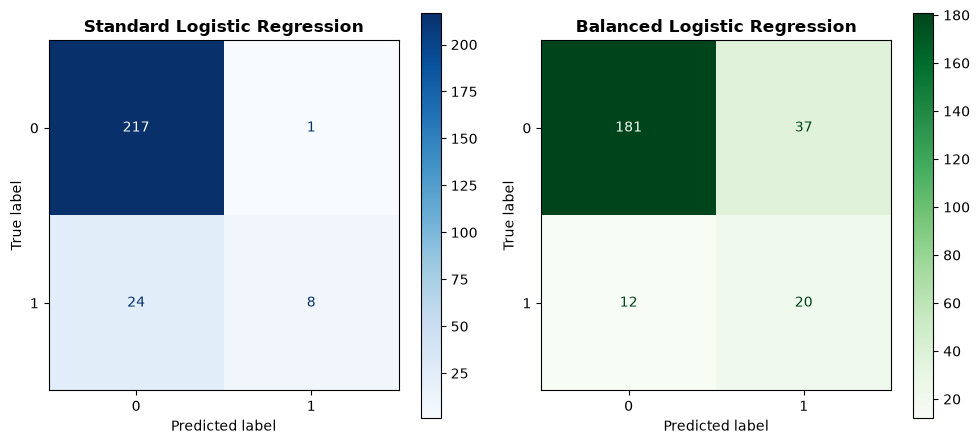

In [4]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.5))

ConfusionMatrixDisplay.from_estimator(clf_lr, X_test, y_test, cmap='Blues', ax=ax1)
ax1.set_title("Standard Logistic Regression", fontweight='bold')

ConfusionMatrixDisplay.from_estimator(clf_lr_balanced, X_test, y_test, cmap='Greens', ax=ax2)
ax2.set_title("Balanced Logistic Regression", fontweight='bold')

plt.tight_layout()
plt.show()

---
### 4. ROC Curves and Area Under the Curve (AUC)

The ROC curve demonstrates how each classifier performs across all possible decision probability thresholds ($0.0 \le \tau \le 1.0$).

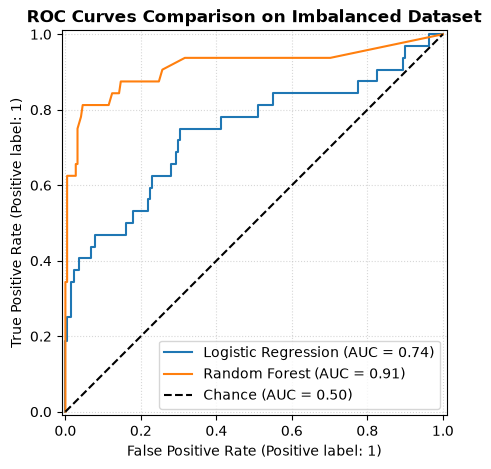

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))

RocCurveDisplay.from_estimator(clf_lr, X_test, y_test, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_estimator(clf_rf, X_test, y_test, name='Random Forest', ax=ax)

ax.plot([0, 1], [0, 1], 'k--', label='Chance (AUC = 0.50)')
ax.set_title("ROC Curves Comparison on Imbalanced Dataset", fontsize=12, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, linestyle=':', alpha=0.5)

plt.show()

### Summary & Next Steps
In this notebook, you mastered:
- Logistic Regression vs Random Forests.
- Evaluating Precision, Recall, and $F_1$-score on imbalanced data.
- Confusion matrix interpretation.
- ROC-AUC curves and decision threshold tuning.

**Next Notebook:** `04_unsupervised_clustering_and_pca.ipynb` — Unsupervised pattern discovery, Principal Component Analysis (PCA), and K-Means clustering.